In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
import os
from glob import glob
import rasterio

In [2]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(torch.cuda.is_available())  # True = CUDA GPU is ready
print(torch.cuda.device_count())  # Number of available GPUs
print(torch.cuda.get_device_name(0))  # Name of first GPU

# Check available CUDA memory
torch.cuda.empty_cache()
free_mem = torch.cuda.mem_get_info()[0] / (1024 ** 3)  # in GB
total_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)  # in GB
print(f"CUDA Free memory: {free_mem:.2f} GB / {total_mem:.2f} GB")

Using device: cuda
True
1
NVIDIA GeForce RTX 3090 Ti
CUDA Free memory: 22.24 GB / 23.99 GB


In [3]:
# Path to your folder (update this path to match your local system)
folder_path = r"D:\RUbel Ahmmed 0421162025\Data\Harirampur Padma\ALL Water Polygon"
# Get all .tif files in the folder
LS_NIR = sorted(glob(os.path.join(folder_path, '*.tif')))
print(f"Found {len(LS_NIR)} GeoTIFF images.")
# Check the number of bands for each .tif file
for tif in LS_NIR:
    with rasterio.open(tif) as src:
        print(f"{os.path.basename(tif)} - Number of bands: {src.count}")
        print(f"Width: {src.width}, Height: {src.height}")

Found 38 GeoTIFF images.
1988_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1989_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1990_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1991_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1992_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1993_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1994_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1995_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1996_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1997_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
Width: 945, Height: 755
1998_LS5_Padma_Harirampur_WaterPolygon_mask.t

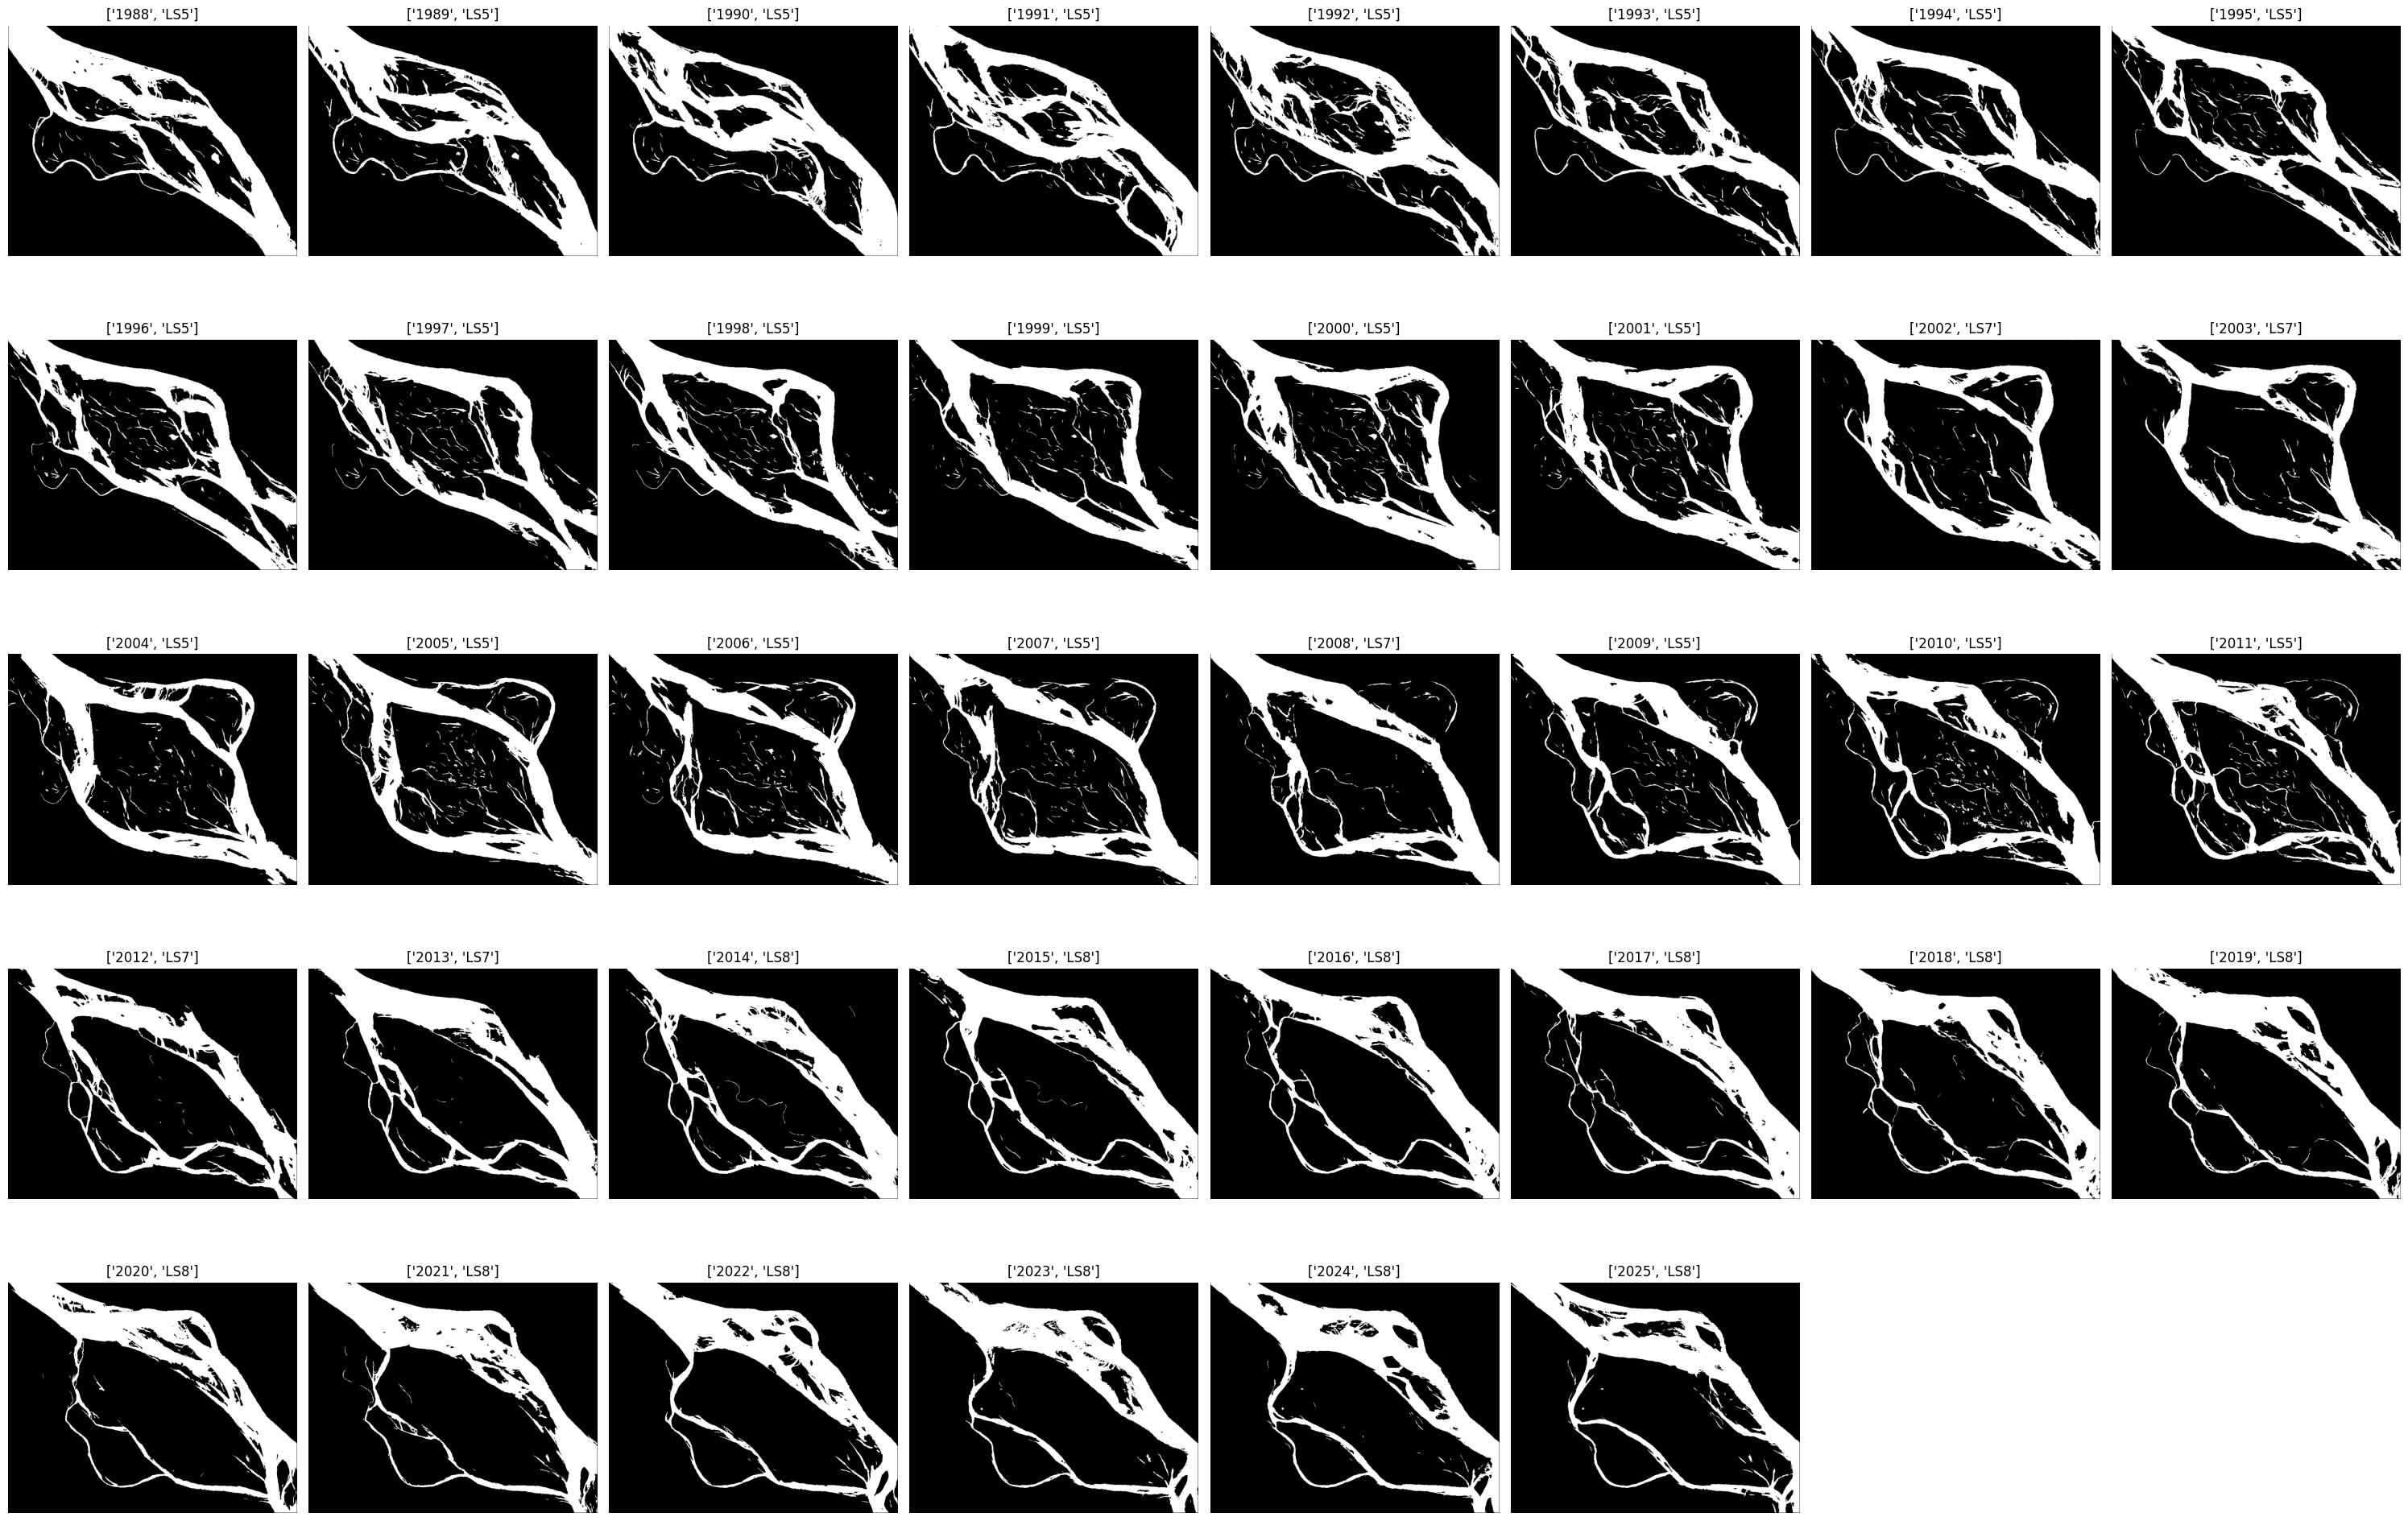

In [4]:
plt.figure(figsize=(30, 20))
for i, tif in enumerate(LS_NIR[:38]):  # Display first 6 images
    with rasterio.open(tif) as src:
        band1 = src.read(1)
    plt.subplot(5, 8, i+1)
    plt.imshow(band1, cmap='gray')
    # Display split upto  2nd _ filename as title
    plt.title(os.path.basename(tif).split('_')[0:2])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [4]:
LS_NIR_List = []
crs = None
transform = None
for i, tif in enumerate(LS_NIR):
    with rasterio.open(tif) as src:
        img = src.read(1).astype(np.float32)  # Read all 3 bands
        # img = np.moveaxis(img, 0, -1)  # Reorder the dimensions (from [bands, height, width] to [height, width, bands])
        LS_NIR_List.append(img)
        if i == 0:
            crs = src.crs
            transform = src.transform
# Stack into time-series array: shape [time, height, width, bands]
LS_NIR_Seq = np.stack(LS_NIR_List).astype(np.float32)
print("Image sequence shape:", LS_NIR_Seq.shape)
print("CRS:", crs)
print("Transform:", transform)

data = torch.tensor(LS_NIR_Seq).squeeze(1)  # [time, channels, height, width]
print("Data tensor shape:", data.shape)

Image sequence shape: (38, 755, 945)
CRS: EPSG:32645
Transform: | 30.00, 0.00, 785220.00|
| 0.00,-30.00, 2630850.00|
| 0.00, 0.00, 1.00|
Data tensor shape: torch.Size([38, 755, 945])


In [5]:
def create_dataset(data, input_seq_len, target_seq_len):
    inputs = []
    targets = []
    total_seq_len = input_seq_len + target_seq_len
    for i in range(len(data) - total_seq_len + 1):
        input_seq = data[i:i+input_seq_len]
        target_seq = data[i+input_seq_len:i+total_seq_len]
        inputs.append(input_seq)
        targets.append(target_seq)
    return torch.stack(inputs), torch.stack(targets)

input_seq_len = 5
target_seq_len = 1
inputs, targets = create_dataset(data, input_seq_len, target_seq_len)
inputs = inputs.unsqueeze(2)  # Add channel dimension
print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)

x_train = inputs[:32]
y_train = targets[:32]
x_val = inputs[32:]
y_val = targets[32:]
x_test = inputs[32:]
y_test = targets[32:]
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


Inputs shape: torch.Size([33, 5, 1, 755, 945])
Targets shape: torch.Size([33, 1, 755, 945])
x_train shape: torch.Size([32, 5, 1, 755, 945])
y_train shape: torch.Size([32, 1, 755, 945])
x_val shape: torch.Size([1, 5, 1, 755, 945])
y_val shape: torch.Size([1, 1, 755, 945])
x_test shape: torch.Size([1, 5, 1, 755, 945])
y_test shape: torch.Size([1, 1, 755, 945])


In [6]:
import torch
import torch.nn as nn

# ConvLSTM Cell
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3, padding=1):
        super().__init__()
        
        self.conv_xi = nn.Conv2d(in_ch, hidden_ch, kernel_size, padding=padding)
        self.conv_xf = nn.Conv2d(in_ch, hidden_ch, kernel_size, padding=padding)
        self.conv_xg = nn.Conv2d(in_ch, hidden_ch, kernel_size, padding=padding)
        self.conv_xo = nn.Conv2d(in_ch, hidden_ch, kernel_size, padding=padding)
        
        self.conv_hi = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        self.conv_hf = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        self.conv_hg = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        self.conv_ho = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        
        self.conv_ci = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        self.conv_cf = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        self.conv_cg = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)
        self.conv_co = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=padding, bias=False)

    def forward(self, x, h, c):
        i = torch.sigmoid(self.conv_xi(x) + self.conv_hi(h) + self.conv_ci(c))
        f = torch.sigmoid(self.conv_xf(x) + self.conv_hf(h) + self.conv_cf(c))
        g = torch.tanh(self.conv_xg(x) + self.conv_hg(h) + self.conv_cg(c))
        o = torch.sigmoid(self.conv_xo(x) + self.conv_ho(h) + self.conv_co(c))
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next


# Bi-Directional ConvLSTM Cell
class BiConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3, padding=1):
        super().__init__()
        self.forward_cell = ConvLSTMCell(in_ch, hidden_ch, kernel_size, padding)
        self.backward_cell = ConvLSTMCell(in_ch, hidden_ch, kernel_size, padding)
        self.hidden_ch = hidden_ch

    def forward(self, x):
        """x: [B, T, C, H, W]"""
        B, T, C, H, W = x.shape
        
        # Forward pass
        hf = torch.zeros(B, self.hidden_ch, H, W, device=x.device)
        cf = torch.zeros(B, self.hidden_ch, H, W, device=x.device)
        forward_outputs = []
        
        for t in range(T):
            hf, cf = self.forward_cell(x[:, t], hf, cf)
            forward_outputs.append(hf.unsqueeze(1))
        
        forward_seq = torch.cat(forward_outputs, dim=1)  # [B, T, hidden_ch, H, W]
        
        # Backward pass
        hb = torch.zeros(B, self.hidden_ch, H, W, device=x.device)
        cb = torch.zeros(B, self.hidden_ch, H, W, device=x.device)
        backward_outputs = []
        
        for t in range(T-1, -1, -1):  # Reverse order
            hb, cb = self.backward_cell(x[:, t], hb, cb)
            backward_outputs.insert(0, hb.unsqueeze(1))  # Insert at beginning
        
        backward_seq = torch.cat(backward_outputs, dim=1)  # [B, T, hidden_ch, H, W]
        
        # Concatenate forward and backward
        combined_seq = torch.cat([forward_seq, backward_seq], dim=2)  # [B, T, 2*hidden_ch, H, W]
        final_hidden = torch.cat([hf, hb], dim=1)  # [B, 2*hidden_ch, H, W]
        
        return combined_seq, final_hidden

# Bi-Directional ConvLSTM Layer
class BiConvLSTMLayer(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3, padding=1):
        super().__init__()
        self.bi_cell = BiConvLSTMCell(in_ch, hidden_ch, kernel_size, padding)
        self.hidden_ch = hidden_ch * 2  # Forward + backward

    def forward(self, x):
        output_seq, hidden = self.bi_cell(x)
        return output_seq, hidden

# Multi-Layer BiConvLSTM Model
class MultiLayerBiConvLSTM_RiverPredictor(nn.Module):
    def __init__(self, in_channels=1, hidden_dims=[32, 64, 128], out_channels=1):
        super().__init__()
        
        # Encoder: 755×945 → 189×237
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        
        # Multi-layer Bi-Directional ConvLSTM
        self.convlstm_layers = nn.ModuleList()
        
        # First layer input: 64 channels from encoder
        self.convlstm_layers.append(BiConvLSTMLayer(64, hidden_dims[0]))
        
        # Subsequent layers: input is 2*hidden_dims[i-1] (forward+backward)
        for i in range(1, len(hidden_dims)):
            self.convlstm_layers.append(BiConvLSTMLayer(
                hidden_dims[i-1] * 2,  # Previous layer's bidirectional output
                hidden_dims[i]          # Current layer's hidden size
            ))
        
        # Attention mechanism
        final_hidden_dim = hidden_dims[-1] * 2  # Bidirectional
        self.attention = nn.Sequential(
            nn.Conv2d(final_hidden_dim, final_hidden_dim // 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(final_hidden_dim // 4, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Skip connection (encoder features to final hidden)
        self.skip_conv = nn.Conv2d(64, final_hidden_dim, kernel_size=1)
        
        # Decoder: 189×237 → 755×945
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(final_hidden_dim, 64, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        B, T, C, H, W = x.shape
        
        # Encode each frame
        encoded_frames = []
        for t in range(T):
            encoded = self.encoder(x[:, t])
            encoded_frames.append(encoded.unsqueeze(1))
        encoded_seq = torch.cat(encoded_frames, dim=1)  # [B, T, 64, 189, 237]
        
        # Process through Bi-Directional ConvLSTM layers
        current_seq = encoded_seq
        for convlstm_layer in self.convlstm_layers:
            current_seq, hidden = convlstm_layer(current_seq)
            # current_seq: [B, T, 2*hidden_dim, H', W']
            # hidden: [B, 2*hidden_dim, H', W'] (combined forward+backward)
        
        # Apply attention to the final hidden state
        attention_map = self.attention(hidden)
        attended_features = hidden * attention_map
        
        # Skip connection from encoder
        skip = self.skip_conv(encoded_frames[-1].squeeze(1))
        combined = attended_features + skip
        
        # Decode back to original size
        output = self.decoder(combined)
        
        # Center crop to exact size
        if output.shape[-2:] != (H, W):
            diff_h = output.shape[-2] - H
            diff_w = output.shape[-1] - W
            start_h = diff_h // 2
            start_w = diff_w // 2
            output = output[:, :, start_h:start_h+H, start_w:start_w+W]
        
        return output

# Create model
model = MultiLayerBiConvLSTM_RiverPredictor(
    in_channels=1,
    hidden_dims=[32, 64, 128],
    out_channels=1
)

# Test
x = torch.randn(4, 5, 1, 755, 945)
output = model(x)
print(f"Output shape: {output.shape}")  # Should be [4, 1, 755, 945]
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([4, 1, 755, 945])
Model parameters: 4,939,010


In [7]:
dateset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dateset, batch_size=8, shuffle=True)
testdataset = TensorDataset(x_test, y_test)
testdataloader = DataLoader(testdataset, batch_size=8, shuffle=False)
validataset = TensorDataset(x_val, y_val)
valdataloader = DataLoader(validataset, batch_size=8, shuffle=False)
for x_batch, y_batch in dataloader:
    print("Batch x shape:", x_batch.shape)
    print("Batch y shape:", y_batch.shape)
    pred = model(x_batch)
    print("Prediction shape:", pred.shape)
    break  # Just to demonstrate one batch

Batch x shape: torch.Size([8, 5, 1, 755, 945])
Batch y shape: torch.Size([8, 1, 755, 945])
Prediction shape: torch.Size([8, 1, 755, 945])


# Training Loss

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np

# Your directory
save_dir = r"D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model 02 ConvBiLSTM Padma dpsk"
os.makedirs(save_dir, exist_ok=True)

# Training parameters
epochs = 50
learning_rate = 0.001
batch_size = 8  # Adjust based on your GPU memory
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

# Best model tracking
best_val_loss = float('inf')
best_epoch = -1

# Training history
train_losses = []
val_losses = []

# Training loop
for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
        train_batches += 1
        
        # if batch_idx % 10 == 0:
        #     print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.6f}")
    
    avg_train_loss = train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for val_inputs, val_targets in valdataloader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)
            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_targets)
            val_loss += loss.item()
            val_batches += 1
    
    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)
    
    # Update learning rate scheduler
    scheduler.step(avg_val_loss)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{epochs} Summary:")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss:   {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 50)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        
        # Save full model
        best_model_path = os.path.join(save_dir, "best_model.pth")
        torch.save(model.state_dict(), best_model_path)
        
        # Save training checkpoint
        checkpoint_path = os.path.join(save_dir, "best_checkpoint.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'best_val_loss': best_val_loss,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, checkpoint_path)
        
        print(f"  ✓ New best model saved! (Val Loss: {avg_val_loss:.6f})")
    
    # Save model every 10 epochs
    if (epoch + 1) % 10 == 0:
        epoch_model_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), epoch_model_path)
        print(f"  ✓ Model saved at epoch {epoch+1}")

# Save final model
final_model_path = os.path.join(save_dir, "final_model.pth")
torch.save(model.state_dict(), final_model_path)

# Save training history
history_path = os.path.join(save_dir, "training_history.npy")
np.save(history_path, {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss
})

print(f"\n{'='*60}")
print("TRAINING COMPLETED")
print(f"{'='*60}")
print(f"Best model saved at epoch {best_epoch}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Models saved in: {save_dir}")
print(f"  - best_model.pth (Best validation performance)")
print(f"  - best_checkpoint.pth (Full training checkpoint)")
print(f"  - final_model.pth (Final trained model)")
print(f"  - training_history.npy (Loss history)")

Using device: cuda

Epoch 1/50 Summary:
  Train Loss: 0.608571
  Val Loss:   0.636545
  Learning Rate: 0.001000
--------------------------------------------------
  ✓ New best model saved! (Val Loss: 0.636545)

Epoch 2/50 Summary:
  Train Loss: 0.431760
  Val Loss:   0.472369
  Learning Rate: 0.001000
--------------------------------------------------
  ✓ New best model saved! (Val Loss: 0.472369)

Epoch 3/50 Summary:
  Train Loss: 0.342191
  Val Loss:   0.312030
  Learning Rate: 0.001000
--------------------------------------------------
  ✓ New best model saved! (Val Loss: 0.312030)

Epoch 4/50 Summary:
  Train Loss: 0.282320
  Val Loss:   0.237566
  Learning Rate: 0.001000
--------------------------------------------------
  ✓ New best model saved! (Val Loss: 0.237566)

Epoch 5/50 Summary:
  Train Loss: 0.248234
  Val Loss:   0.215488
  Learning Rate: 0.001000
--------------------------------------------------
  ✓ New best model saved! (Val Loss: 0.215488)

Epoch 6/50 Summary:
  Tra

# Model Evaluation

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def evaluate_model(model, test_loader, device='cpu'):
    """Comprehensive evaluation of river prediction model"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    return all_preds, all_targets

def calculate_river_metrics(y_true, y_pred):
    """Calculate river-specific metrics"""
    y_true_np = y_true.cpu().numpy().flatten()
    y_pred_np = y_pred.cpu().numpy().flatten()
    
    # Basic classification metrics
    cm = confusion_matrix(y_true_np, y_pred_np)
    tn, fp, fn, tp = cm.ravel()
    
    # River-specific metrics
    total_pixels = y_true_np.size
    water_pixels_true = np.sum(y_true_np == 1)
    water_pixels_pred = np.sum(y_pred_np == 1)
    
    # Hydrological metrics
    iou_water = tp / (tp + fp + fn + 1e-10)
    iou_land = tn / (tn + fp + fn + 1e-10)
    
    # Connectivity metrics (approximate)
    from scipy import ndimage
    pred_water = y_pred[0, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    true_water = y_true[0, 0].cpu().numpy() if y_true.dim() > 2 else y_true.cpu().numpy()
    
    # Number of connected water bodies
    labeled_pred, num_features_pred = ndimage.label(pred_water > 0.5)
    labeled_true, num_features_true = ndimage.label(true_water > 0.5)
    
    metrics = {
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'precision_water': tp / (tp + fp + 1e-10),
        'recall_water': tp / (tp + fn + 1e-10),
        'f1_water': 2 * tp / (2 * tp + fp + fn + 1e-10),
        'iou_water': iou_water,
        'iou_land': iou_land,
        'water_pixels_true': water_pixels_true,
        'water_pixels_pred': water_pixels_pred,
        'water_area_ratio_true': water_pixels_true / total_pixels,
        'water_area_ratio_pred': water_pixels_pred / total_pixels,
        'num_water_bodies_true': num_features_true,
        'num_water_bodies_pred': num_features_pred,
        'false_positive_rate': fp / (fp + tn + 1e-10),
        'false_negative_rate': fn / (fn + tp + 1e-10),
    }
    
    return metrics, cm


def generate_detailed_report(metrics, model_name="Conv3D River Predictor"):
    """Generate detailed evaluation report"""
    report = f"""
    {'='*60}
    RIVER PLANFORM PREDICTION EVALUATION REPORT
    {'='*60}
    Model: {model_name}
    Timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
    
    {'-'*60}
    CLASSIFICATION METRICS:
    {'-'*60}
    Accuracy:           {metrics['accuracy']:.4f}
    Precision (Water):  {metrics['precision_water']:.4f}
    Recall (Water):     {metrics['recall_water']:.4f}
    F1-Score (Water):   {metrics['f1_water']:.4f}
    
    {'-'*60}
    SEGMENTATION METRICS:
    {'-'*60}
    IoU (Water):        {metrics['iou_water']:.4f}
    IoU (Land):         {metrics['iou_land']:.4f}
    False Positive Rate: {metrics['false_positive_rate']:.4f}
    False Negative Rate: {metrics['false_negative_rate']:.4f}
    
    {'-'*60}
    RIVER MORPHOLOGY:
    {'-'*60}
    Water Pixels (True):  {metrics['water_pixels_true']:,}
    Water Pixels (Pred):  {metrics['water_pixels_pred']:,}
    Water Area Ratio:     {metrics['water_area_ratio_true']:.4f}
    Water Bodies (True):  {metrics['num_water_bodies_true']}
    Water Bodies (Pred):  {metrics['num_water_bodies_pred']}
    
    {'='*60}
    """
    print(report)
    
    # Return as dictionary for further analysis
    return metrics

# ====== MAIN EVALUATION PIPELINE ======
if __name__ == "__main__":
    # Load your trained model
    model = MultiLayerBiConvLSTM_RiverPredictor(in_channels=1,hidden_dims=[32, 64, 128],out_channels=1)  # Your model class
    model.load_state_dict(torch.load(r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model 02 ConvBiLSTM Padma dpsk\best_model.pth'))
    model.eval()
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # 1. Evaluate on test data
    print("Evaluating model on test data...")
    y_pred, y_true = evaluate_model(model, testdataloader, device)
    
    # 2. Calculate metrics
    metrics, cm = calculate_river_metrics(y_true, y_pred)
    
    # 3. Generate report
    generate_detailed_report(metrics)
    
    

Evaluating model on test data...

    RIVER PLANFORM PREDICTION EVALUATION REPORT
    Model: Conv3D River Predictor
    Timestamp: 2026-01-30 15:27:52

    ------------------------------------------------------------
    CLASSIFICATION METRICS:
    ------------------------------------------------------------
    Accuracy:           0.9357
    Precision (Water):  0.7987
    Recall (Water):     0.9086
    F1-Score (Water):   0.8502

    ------------------------------------------------------------
    SEGMENTATION METRICS:
    ------------------------------------------------------------
    IoU (Water):        0.7394
    IoU (Land):         0.9214
    False Positive Rate: 0.0575
    False Negative Rate: 0.0914

    ------------------------------------------------------------
    RIVER MORPHOLOGY:
    ------------------------------------------------------------
    Water Pixels (True):  143,162
    Water Pixels (Pred):  162,857
    Water Area Ratio:     0.2007
    Water Bodies (True):  125

# Loss histroy plot

Keys in history: dict_keys(['train_losses', 'val_losses', 'best_epoch', 'best_val_loss'])


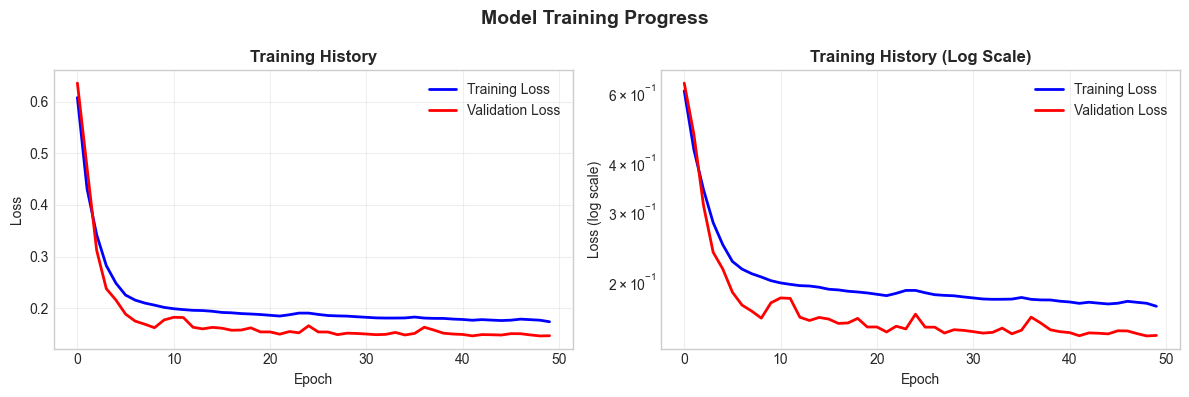

In [10]:
def plot_training_history(loss_history, val_loss_history, save_path=None):
    """Plot training and validation loss history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curves
    ax1.plot(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax1.plot(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training History', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Log scale for better visualization
    ax2.semilogy(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax2.semilogy(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss (log scale)')
    ax2.set_title('Training History (Log Scale)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Load the training history
train_history_path = r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model 02 ConvBiLSTM Padma dpsk\training_history.npy'
history = np.load(train_history_path, allow_pickle=True).item()
print("Keys in history:", history.keys())
# Keys in history: dict_keys(['train_losses', 'val_losses', 'best_epoch', 'best_val_loss'])
train_losses = history['train_losses']
val_losses = history['val_losses']
# Plot training history
plot_training_history(train_losses, val_losses, save_path=None)

# Actual Vs Prediction Plot

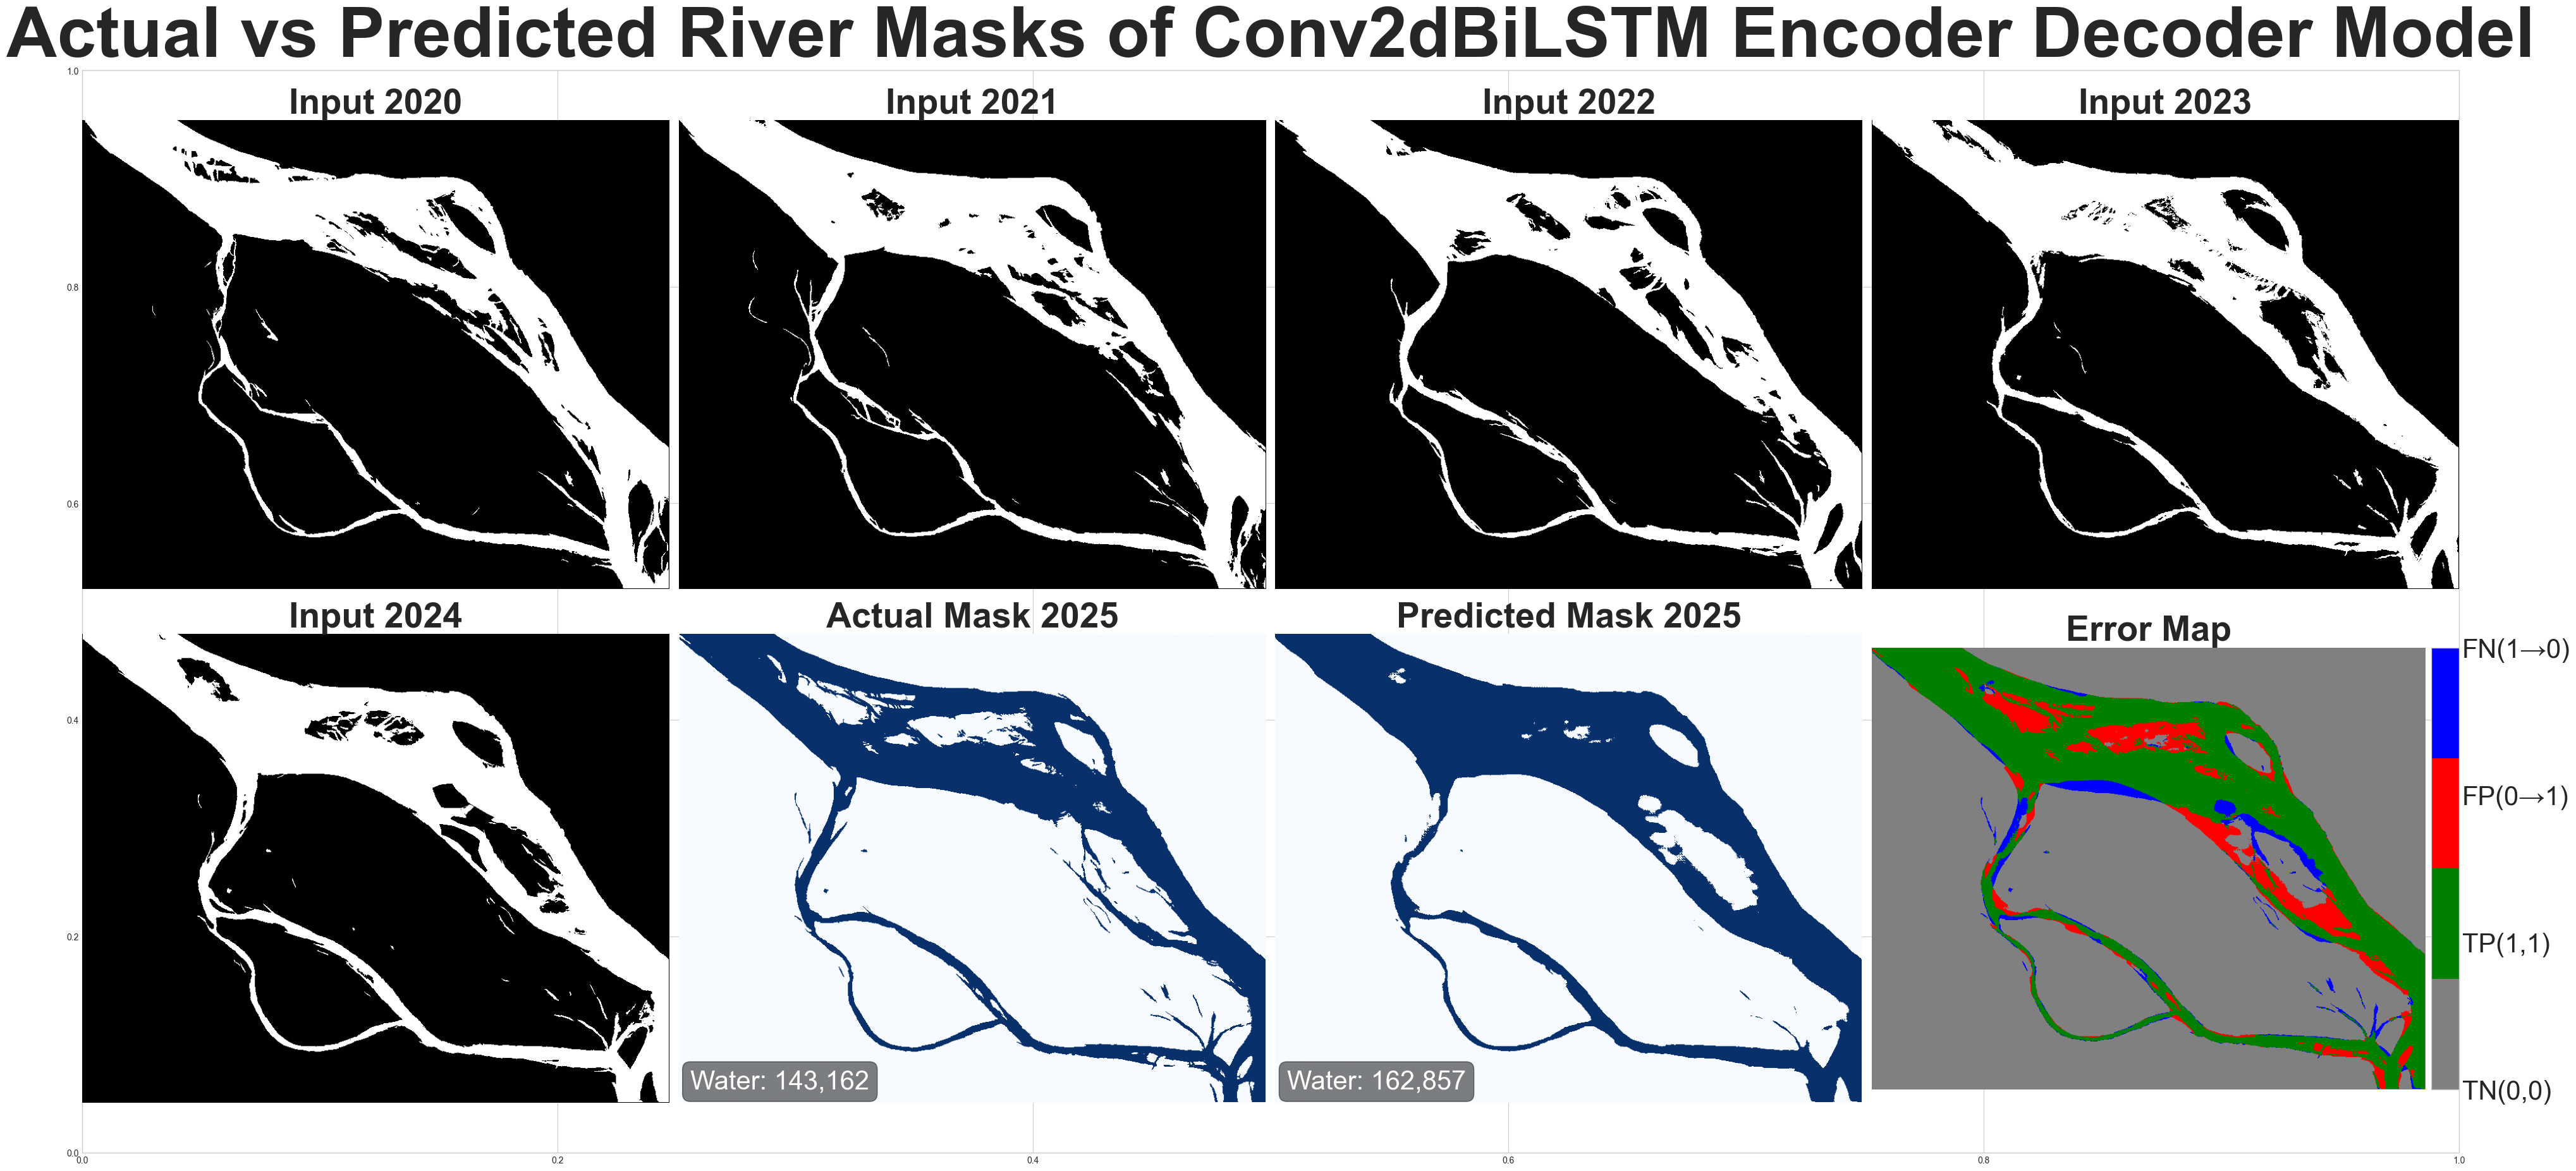

In [12]:
def visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None):
    """Enhanced visualization with metrics - assuming x_test has shape [batch, seq_len, 1, H, W]"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(x_test, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    x_test_bin = x_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Classification map
    result = torch.zeros_like(y_test_bin, dtype=torch.int8)
    result[(y_test_bin == 1) & (y_pred_bin == 1)] = 1     # True Positive
    result[(y_test_bin == 0) & (y_pred_bin == 1)] = 2     # False Positive
    result[(y_test_bin == 1) & (y_pred_bin == 0)] = 3     # False Negative
    
    # Colors and labels
    cmap = ListedColormap(['gray', 'green', 'red', 'blue'])
    labels = ['TN(0,0)', 'TP(1,1)', 'FP(0→1)', 'FN(1→0)']
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Create figure with 2×4 grid
    fig = plt.figure(figsize=(40, 20))
    
    # Assuming x_test shape: [batch, sequence_len=5, 1, H, W]
    time_labels = ['2020', '2021', '2022', '2023', '2024']
    plt.title('Actual vs Predicted River Masks of Conv2dBiLSTM Encoder Decoder Model', fontsize=80, fontweight='bold')
    # Plot all 5 input frames (columns 1-5)
    for i in range(5):
        ax = plt.subplot(2, 4, i+1)
        
        # Get the i-th frame in the sequence
        if x_test.dim() == 5:  # [batch, seq_len, channels, H, W]
            img_to_show = x_test[sample_idx, i, 0].cpu().numpy()
        elif x_test.dim() == 4:  # [batch, seq_len*channels, H, W]
            img_to_show = x_test[sample_idx, i].cpu().numpy()
        else:
            img_to_show = x_test[sample_idx].cpu().numpy()
        
        ax.imshow(img_to_show, cmap='gray')
        ax.set_title(f'Input {time_labels[i]}', fontsize=40, fontweight='bold')
        ax.axis('off')
    
    # 6: Actual River Mask (t)
    ax6 = plt.subplot(2, 4, 6)
    actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.dim() > 2 else y_test.cpu().numpy()
    ax6.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
    ax6.set_title('Actual Mask 2025', fontsize=40, fontweight='bold')
    ax6.axis('off')
    ax6.text(0.02, 0.02, f'Water: {metrics["water_pixels_true"]:,}', 
             transform=ax6.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 7: Predicted River Mask (t)
    ax7 = plt.subplot(2, 4, 7)
    pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    ax7.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
    ax7.set_title('Predicted Mask 2025', fontsize=40, fontweight='bold')
    ax7.axis('off')
    ax7.text(0.02, 0.02, f'Water: {metrics["water_pixels_pred"]:,}', 
             transform=ax7.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 8: Error Classification
    ax8 = plt.subplot(2, 4, 8)
    error_map = result[sample_idx, 0].cpu().numpy() if result.dim() > 2 else result.cpu().numpy()
    im = ax8.imshow(error_map, cmap=cmap, vmin=0, vmax=3)
    ax8.set_title('Error Map', fontsize=40, fontweight='bold')
    ax8.axis('off')
    
    # Add colorbar for error map
    divider = make_axes_locatable(ax8)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(labels, fontsize=30)
   
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()

visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None)

# Evaluation Matrix plot

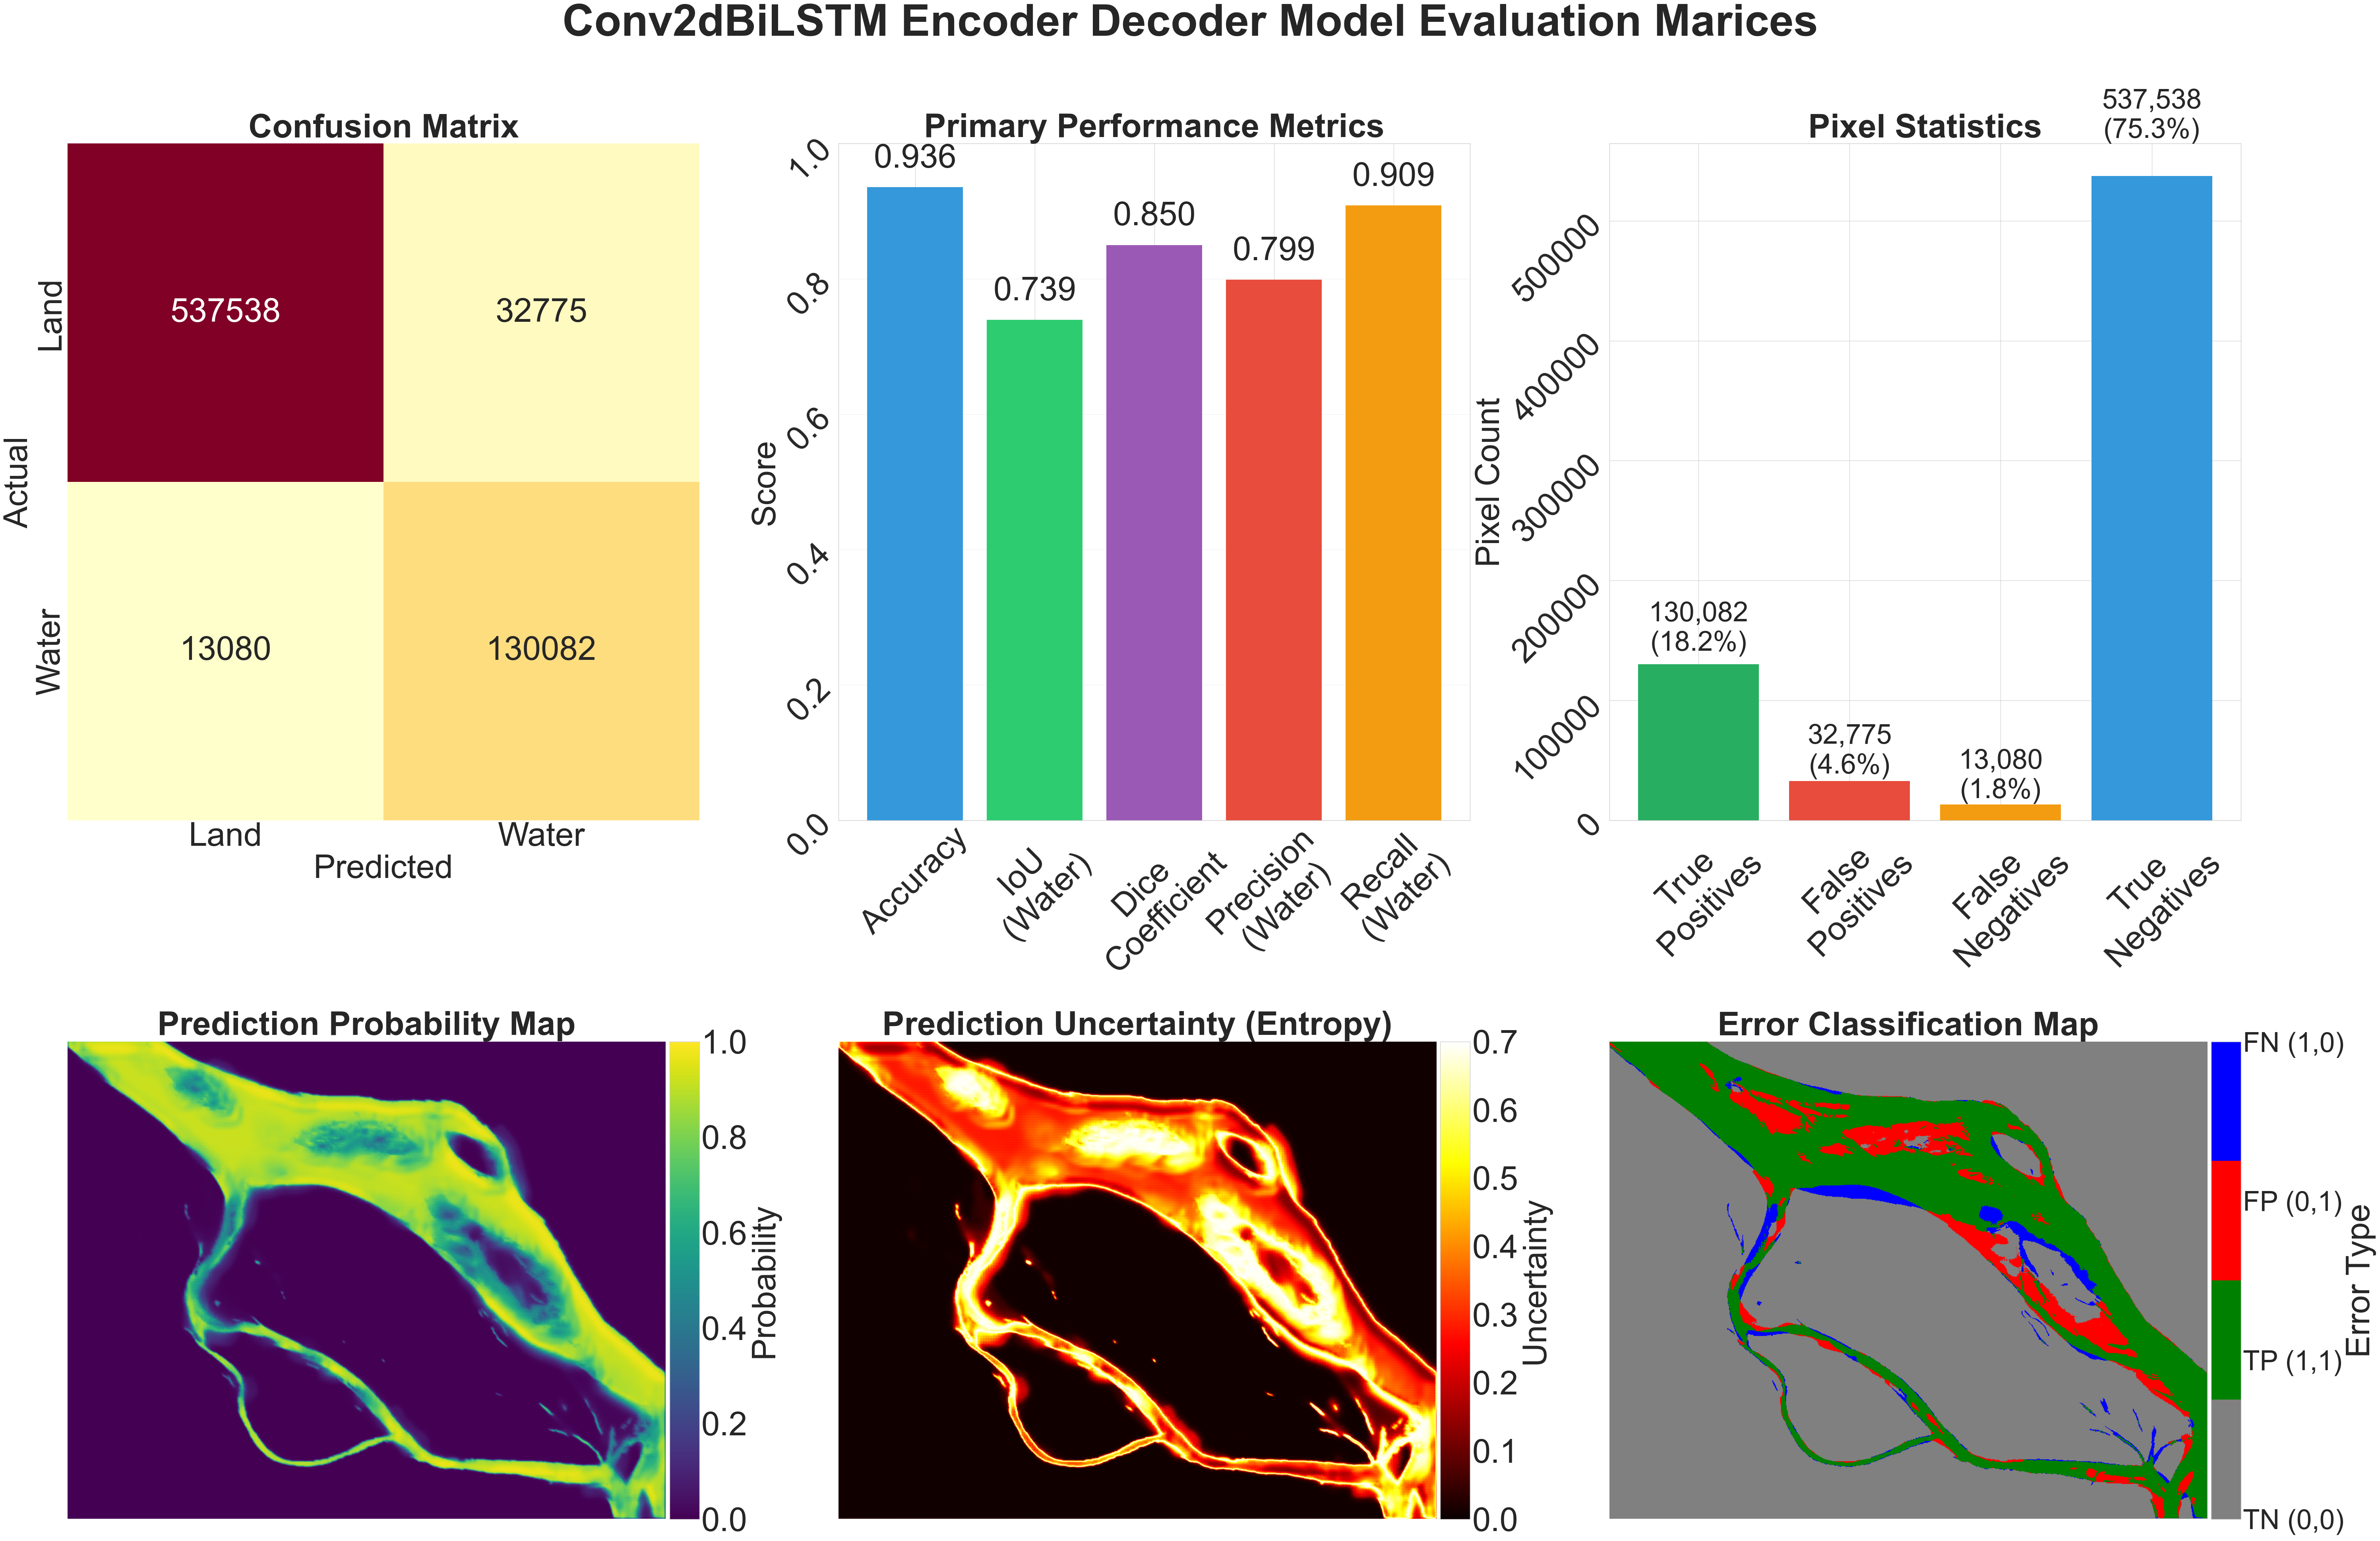

In [14]:
def Matricesplot(y_test, y_pred, model=None, x_test=None, device='cpu', sample_idx=0, save_path=None):
    """Enhanced visualization with metrics including probability and uncertainty maps"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(y_pred, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Get probability map if model and x_test are provided
    prob_map = None
    if model is not None and x_test is not None:
        with torch.no_grad():
            model.eval()
            if isinstance(x_test, np.ndarray):
                x_test = torch.from_numpy(x_test)
            x_test = x_test.to(device)
            predictions = model(x_test)
            
            if predictions.dim() > 2:
                prob_map = predictions[sample_idx, 0].cpu().numpy() if predictions.shape[1] == 1 else predictions[sample_idx].cpu().numpy()
            else:
                prob_map = predictions.cpu().numpy()
    
    # Create figure with 3x2 grid (6 plots total)
    fig = plt.figure(figsize=(60, 40))
    
    # 1. Confusion Matrix Heatmap
    ax1 = plt.subplot(2, 3, 1)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                          annot_kws={"size": 60},
                          xticklabels=['Land', 'Water'], 
                          yticklabels=['Land', 'Water'],
                          ax=ax1,
                          cbar=False)
    ax1.set_title('Confusion Matrix', fontsize=60, fontweight='bold')
    ax1.set_xlabel('Predicted', fontsize=60)
    ax1.set_ylabel('Actual', fontsize=60)
    ax1.tick_params(axis='both', labelsize=60)
    
    # 2. Primary Metrics
    ax2 = plt.subplot(2, 3, 2)
    primary_metrics = ['Accuracy', 'IoU\n(Water)', 'Dice\nCoefficient', 'Precision\n(Water)', 'Recall\n(Water)']
    primary_values = [
        metrics['accuracy'],
        metrics['iou_water'],
        metrics.get('dice_water', metrics.get('f1_water', 0)),
        metrics['precision_water'],
        metrics['recall_water']
    ]
    
    colors1 = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
    bars1 = ax2.bar(primary_metrics, primary_values, color=colors1)
    ax2.set_ylim([0, 1])
    ax2.set_title('Primary Performance Metrics', fontsize=60, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=60)
    ax2.tick_params(axis='both', labelsize=60, rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars1, primary_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=60)
    
    # 3. Pixel Statistics
    ax3 = plt.subplot(2, 3, 3)
    
    # Calculate pixel statistics
    total_pixels = cm.sum()
    tp, fp, fn, tn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]
    
    stats_labels = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
    stats_values = [tp, fp, fn, tn]
    stats_percentages = [tp/total_pixels*100, fp/total_pixels*100, 
                         fn/total_pixels*100, tn/total_pixels*100]
    
    colors3 = ['#27ae60', '#e74c3c', '#f39c12', '#3498db']
    bars3 = ax3.bar(stats_labels, stats_values, color=colors3)
    ax3.set_title('Pixel Statistics', fontsize=60, fontweight='bold')
    ax3.set_ylabel('Pixel Count', fontsize=60)
    ax3.tick_params(axis='both', labelsize=60, rotation=45)
    
    # Add both count and percentage
    for bar, val, pct in zip(bars3, stats_values, stats_percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=50)
    
    # 4. Probability Map (if available)
    ax4 = plt.subplot(2, 3, 4)
    if prob_map is not None:
        im1 = ax4.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax4.set_title('Prediction Probability Map', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1)
        cbar1.ax.tick_params(labelsize=60)
        cbar1.set_label('Probability', fontsize=60)
    else:
        # If no probability map, show actual mask
        if y_test.dim() > 2:
            actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
        else:
            actual_mask = y_test.cpu().numpy()
        
        im1 = ax4.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
        ax4.set_title('Actual Water Mask', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1, ticks=[0, 1])
        cbar1.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar1.set_label('Class', fontsize=60)
    
    # 5. Uncertainty Map (if probability map is available)
    ax5 = plt.subplot(2, 3, 5)
    if prob_map is not None:
        # Calculate entropy as uncertainty measure
        prob_map_clipped = np.clip(prob_map, 1e-10, 1 - 1e-10)  # Avoid log(0)
        uncertainty = -prob_map_clipped * np.log(prob_map_clipped) - (1 - prob_map_clipped) * np.log(1 - prob_map_clipped)
        
        im2 = ax5.imshow(uncertainty, cmap='hot', vmin=0, vmax=0.7)
        ax5.set_title('Prediction Uncertainty (Entropy)', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2)
        cbar2.ax.tick_params(labelsize=60)
        cbar2.set_label('Uncertainty', fontsize=60)
    else:
        # If no uncertainty map, show predicted mask
        if y_pred.dim() > 2:
            pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
        else:
            pred_mask = y_pred.cpu().numpy()
        
        im2 = ax5.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
        ax5.set_title('Predicted Water Mask', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2, ticks=[0, 1])
        cbar2.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar2.set_label('Class', fontsize=60)
    
    # 6. Error Classification Map
    ax6 = plt.subplot(2, 3, 6)
    
    # Get actual and predicted masks
    if y_test.dim() > 2:
        actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
    else:
        actual_mask = y_test.cpu().numpy()
    
    if y_pred.dim() > 2:
        pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
    else:
        pred_mask = y_pred.cpu().numpy()
    
    # Create error map
    pred_mask_bin = (pred_mask > 0.5).astype(np.int32)
    error_map = np.zeros_like(actual_mask, dtype=np.int32)
    error_map[(actual_mask == 0) & (pred_mask_bin == 0)] = 0  # TN
    error_map[(actual_mask == 1) & (pred_mask_bin == 1)] = 1  # TP
    error_map[(actual_mask == 0) & (pred_mask_bin == 1)] = 2  # FP
    error_map[(actual_mask == 1) & (pred_mask_bin == 0)] = 3  # FN
    
    cmap_error = ListedColormap(['gray', 'green', 'red', 'blue'])
    im3 = ax6.imshow(error_map, cmap=cmap_error, vmin=0, vmax=3)
    ax6.set_title('Error Classification Map', fontsize=60, fontweight='bold')
    ax6.axis('off')
    divider3 = make_axes_locatable(ax6)
    cax3 = divider3.append_axes("right", size="5%", pad=0.1)
    cbar3 = plt.colorbar(im3, cax=cax3, ticks=[0, 1, 2, 3])
    cbar3.ax.set_yticklabels(['TN (0,0)', 'TP (1,1)', 'FP (0,1)', 'FN (1,0)'], fontsize=50)
    cbar3.set_label('Error Type', fontsize=60)
    
    plt.suptitle('Conv2dBiLSTM Encoder Decoder Model Evaluation Marices', fontsize=80, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # if save_path:
    #     plt.savefig(save_path, dpi=100, bbox_inches='tight')
    #     print(f"Metrics visualization saved to {save_path}")
    
    plt.show()
    
Matricesplot(y_test, y_pred, model=model, x_test=x_test, device=device)